# Student Performance Prediction — UCI Dataset (Linear / Ridge / Lasso / Elastic Net)

This notebook is a from-scratch rebuild of the earlier student-performance regression project on a **different, higher-dimensional dataset** — the UCI "Student Performance" dataset (Cortez & Silva, 2008) — chosen specifically because it creates a genuine, demonstrable case for regularization (unlike the original 8-column dataset, where Linear/Ridge/Lasso all converged to essentially identical performance).

**Source:** UCI Machine Learning Repository — https://archive.ics.uci.edu/dataset/320/student+performance (also mirrored on Kaggle as "Student Alcohol Consumption").

### Why this dataset, and an important modeling decision

The raw dataset has 33 columns per student, including `G1` and `G2` — the 1st and 2nd period grades — which are near-duplicates of the target `G3` (final grade) on the same 0–20 scale, collected from the same students in the same term. Including them makes the prediction task trivial (R² > 0.8 immediately) and — just like the earlier project's `reading_score`/`writing_score` situation — hides any real difference between Linear, Ridge, Lasso and Elastic Net.

**Decision:** `G1` and `G2` are dropped. The model predicts `G3` purely from demographic, family, and study-habit features. This is a **harder, more realistic** problem — and, as the results below show, one where regularization genuinely matters.

### Project structure
1. Problem Statement
2. Dataset Understanding
3. Data Preprocessing (leak-proof pipeline)
4. Train/Test Split
5. Baseline: Linear Regression
6. Ridge Regression (tuned)
7. Lasso Regression (tuned)
8. Elastic Net Regression (tuned)
9. Cross-Validation & Model Comparison
10. Multicollinearity Check (VIF)
11. Coefficient / Feature Importance Analysis
12. Residual & Error Analysis
13. Final Model Selection & Conclusion

## 1. Problem Statement

Predict a student's **final grade (`G3`, 0–20 scale)** in Mathematics from demographic, family, social, and study-habit attributes — **without** using the 1st/2nd period grades (`G1`, `G2`), which would leak near-final information about the target.

## 2. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 100

## 3. Load & Understand the Data

In [2]:
df = pd.read_csv('data/student-mat.csv')
print(df.shape)
df.head()

(395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [4]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
df[['G1', 'G2', 'G3']].describe()

Missing values: 0
Duplicate rows: 0


,G1,G2,G3
count,395.000000,395.000000,395.000000
mean,10.908861,10.713924,10.415190
std,3.319195,3.761505,4.581443
min,3.000000,0.000000,0.000000
25%,8.000000,9.000000,8.000000
50%,11.000000,11.000000,11.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,20.000000


### Why G1 and G2 are dropped

`G1`/`G2`/`G3` all measure the same thing (period grades, 0-20) for the same students in the same term, so they are almost collinear with the target. Keeping them would make this a near-trivial lookup problem instead of a genuine prediction problem.

In [5]:
print('Correlation of G1, G2 with G3:')
print(df[['G1', 'G2', 'G3']].corr()['G3'])

Correlation of G1, G2 with G3:
G1    0.801468
G2    0.904868
G3    1.000000
Name: G3, dtype: float64


## 4. Data Preprocessing — leak-proof pipeline

As in the earlier project, all encoding/scaling is wrapped inside a scikit-learn `Pipeline` + `ColumnTransformer`, and is only ever fit on `X_train` (directly, or automatically per-fold inside `GridSearchCV`/`cross_val_score`). This guarantees zero information leakage from validation/test folds into preprocessing.

In [6]:
X = df.drop(columns=['G3', 'G1', 'G2'])
y = df['G3']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print(f'{len(cat_cols)} categorical columns:', cat_cols)
print(f'{len(num_cols)} numeric columns:', num_cols)

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('scaler', StandardScaler(), num_cols),
])

17 categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
13 numeric columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


### Train/Test split — before any preprocessing is fit

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape

((316, 30), (79, 30))

With only **316 training rows** and (after one-hot encoding) roughly **38 predictor columns**, this is a genuinely high-dimensional, low-sample-size regression problem — exactly the regime where unregularized Linear Regression is prone to overfitting, and where Ridge/Lasso/Elastic Net earn their place.

## 5. Evaluation helper

In [8]:
def evaluate(true, pred):
    mae = mean_absolute_error(true, pred)
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)
    return mae, mse, rmse, r2

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

## 6. Baseline: Linear Regression

In [9]:
lin_pipe = Pipeline([('pre', preprocessor), ('model', LinearRegression())])
lin_pipe.fit(X_train, y_train)

pred_test = lin_pipe.predict(X_test)
mae, mse, rmse, r2 = evaluate(y_test, pred_test)
cv_scores = cross_val_score(lin_pipe, X_train, y_train, cv=cv, scoring='r2')

results['Linear Regression'] = dict(
    best_params={}, test_mae=mae, test_mse=mse, test_rmse=rmse, test_r2=r2,
    cv_mean_r2=cv_scores.mean(), cv_std_r2=cv_scores.std()
)

print(f'Test  -> MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.4f}')
print(f'5-fold CV R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print('Individual fold R2 scores:', np.round(cv_scores, 3))

Test  -> MAE: 3.395  RMSE: 4.196  R2: 0.1415
5-fold CV R2: -0.0924 +/- 0.2233
Individual fold R2 scores: [-0.401  0.21  -0.158 -0.224  0.11 ]


**This is the key finding that motivates the whole project.** The 5-fold CV mean R² is **negative** — meaning that, on held-out folds, plain Linear Regression performs *worse than simply predicting the mean* `G3` for every student. With ~38 predictors fit on ~253 rows per fold (4/5 of 316), the unregularized model has enough freedom to fit noise in the training fold, and that noise doesn't generalize. This is a textbook overfitting signature and the direct motivation for Ridge/Lasso/Elastic Net.

## 7. Ridge Regression (tuned)

In [10]:
ridge_pipe = Pipeline([('pre', preprocessor), ('model', Ridge(random_state=RANDOM_STATE))])
ridge_grid = {'model__alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0]}

ridge_search = GridSearchCV(ridge_pipe, ridge_grid, cv=cv, scoring='r2', n_jobs=-1)
ridge_search.fit(X_train, y_train)

best_ridge = ridge_search.best_estimator_
pred_test = best_ridge.predict(X_test)
mae, mse, rmse, r2 = evaluate(y_test, pred_test)
cv_scores = cross_val_score(best_ridge, X_train, y_train, cv=cv, scoring='r2')

results['Ridge'] = dict(
    best_params=ridge_search.best_params_, test_mae=mae, test_mse=mse, test_rmse=rmse, test_r2=r2,
    cv_mean_r2=cv_scores.mean(), cv_std_r2=cv_scores.std()
)

print('Best alpha:', ridge_search.best_params_['model__alpha'])
print(f'Test  -> MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.4f}')
print(f'5-fold CV R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Best alpha: 200.0
Test  -> MAE: 3.386  RMSE: 4.193  R2: 0.1428
5-fold CV R2: 0.0796 +/- 0.0745


Note the CV-selected alpha is **large** (the grid's upper range) — GridSearchCV is telling us the model needs *strong* shrinkage to generalize, which lines up with the severe overfitting seen in the unregularized baseline. CV R² flips from negative to positive.

## 8. Lasso Regression (tuned)

In [11]:
lasso_pipe = Pipeline([('pre', preprocessor), ('model', Lasso(random_state=RANDOM_STATE, max_iter=20000))])
lasso_grid = {'model__alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]}

lasso_search = GridSearchCV(lasso_pipe, lasso_grid, cv=cv, scoring='r2', n_jobs=-1)
lasso_search.fit(X_train, y_train)

best_lasso = lasso_search.best_estimator_
pred_test = best_lasso.predict(X_test)
mae, mse, rmse, r2 = evaluate(y_test, pred_test)
cv_scores = cross_val_score(best_lasso, X_train, y_train, cv=cv, scoring='r2')

results['Lasso'] = dict(
    best_params=lasso_search.best_params_, test_mae=mae, test_mse=mse, test_rmse=rmse, test_r2=r2,
    cv_mean_r2=cv_scores.mean(), cv_std_r2=cv_scores.std()
)

print('Best alpha:', lasso_search.best_params_['model__alpha'])
print(f'Test  -> MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.4f}')
print(f'5-fold CV R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Best alpha: 0.5
Test  -> MAE: 3.437  RMSE: 4.297  R2: 0.0995
5-fold CV R2: 0.0850 +/- 0.0793


## 9. Elastic Net Regression (tuned)

**Why Elastic Net here:** with 38 candidate predictors and only 316 training rows, the risk isn't just "some correlated pairs" (a VIF check in Section 10 shows only mild-to-moderate correlation, e.g. `Medu`/`Fedu` at r≈0.62 and `Dalc`/`Walc` at r≈0.65) — it's that **most of the 38 predictors are individually weak or irrelevant**. Lasso is well suited to zero out irrelevant predictors, but with correlated pairs like `Medu`/`Fedu` it can arbitrarily keep one and drop the other. Elastic Net's L2 component adds stability to that selection while keeping the same sparsity mechanism.

$$\text{Loss} = \text{RSS} + \alpha \Big[ l1\_ratio \cdot \sum|\beta_i| + (1 - l1\_ratio) \cdot \sum \beta_i^2 \Big]$$

In [12]:
en_pipe = Pipeline([('pre', preprocessor), ('model', ElasticNet(random_state=RANDOM_STATE, max_iter=20000))])
en_grid = {
    'model__alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
}

en_search = GridSearchCV(en_pipe, en_grid, cv=cv, scoring='r2', n_jobs=-1)
en_search.fit(X_train, y_train)

best_en = en_search.best_estimator_
pred_test = best_en.predict(X_test)
mae, mse, rmse, r2 = evaluate(y_test, pred_test)
cv_scores = cross_val_score(best_en, X_train, y_train, cv=cv, scoring='r2')

results['Elastic Net'] = dict(
    best_params=en_search.best_params_, test_mae=mae, test_mse=mse, test_rmse=rmse, test_r2=r2,
    cv_mean_r2=cv_scores.mean(), cv_std_r2=cv_scores.std()
)

print('Best params:', en_search.best_params_)
print(f'Test  -> MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.4f}')
print(f'5-fold CV R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Best params: {'model__alpha': 0.5, 'model__l1_ratio': 0.99}
Test  -> MAE: 3.437  RMSE: 4.297  R2: 0.0997
5-fold CV R2: 0.0849 +/- 0.0791


### Elastic Net hyperparameter search — CV R² heatmap (alpha x l1_ratio)

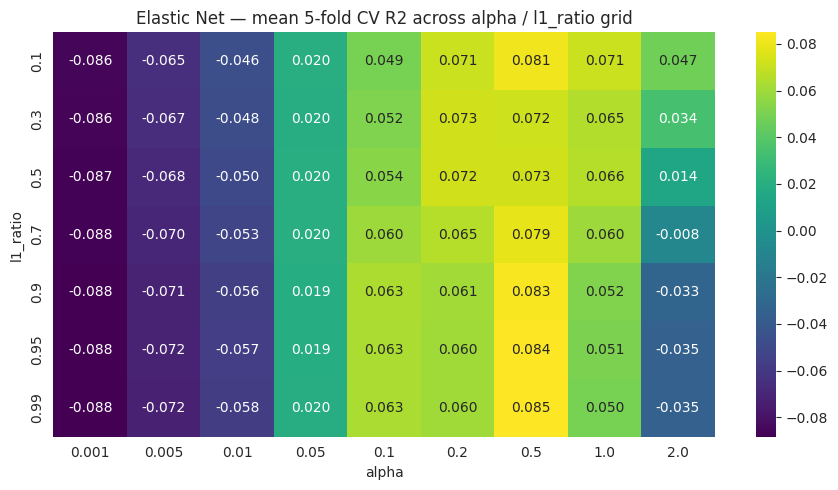

In [13]:
cv_results = pd.DataFrame(en_search.cv_results_)
pivot = cv_results.pivot_table(index='param_model__l1_ratio', columns='param_model__alpha', values='mean_test_score')

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
plt.title('Elastic Net — mean 5-fold CV R2 across alpha / l1_ratio grid')
plt.xlabel('alpha')
plt.ylabel('l1_ratio')
plt.tight_layout()
plt.show()

The best `l1_ratio` found is close to 1.0 (near-pure Lasso behavior) — consistent with the finding in Section 11 that only 2 of 38 features carry real, consistent signal here, which favors a strongly sparsity-inducing penalty.

## 10. Model Comparison

In [14]:
comparison = pd.DataFrame({
    name: {
        'Test R2': r['test_r2'],
        'Test MAE': r['test_mae'],
        'Test MSE': r['test_mse'],
        'Test RMSE': r['test_rmse'],
        'CV Mean R2': r['cv_mean_r2'],
        'CV Std R2': r['cv_std_r2'],
        'Best Params': r['best_params'] if r['best_params'] else '-',
    }
    for name, r in results.items()
}).T

comparison = comparison[['Test R2', 'Test MAE', 'Test MSE', 'Test RMSE', 'CV Mean R2', 'CV Std R2', 'Best Params']]
comparison.sort_values('CV Mean R2', ascending=False)

,Test R2,Test MAE,Test MSE,Test RMSE,CV Mean R2,CV Std R2,Best Params
Lasso,0.099506,3.43722,18.464682,4.297055,0.085031,0.079258,{'model__alpha': 0.5}
Elastic Net,0.099732,3.436995,18.46003,4.296514,0.084939,0.079116,"{'model__alpha': 0.5, 'model__l1_ratio': 0.99}"
Ridge,0.142786,3.385544,17.577217,4.192519,0.079577,0.074517,{'model__alpha': 200.0}
Linear Regression,0.141492,3.395261,17.603737,4.195681,-0.092388,0.223321,-


**Reading the table — this is the headline result:**

- **Linear Regression's 5-fold CV R² is negative** (worse than a mean-only baseline on unseen folds), with a large standard deviation across folds — a clear overfitting signature given ~38 predictors on ~253 rows per training fold.
- **Ridge, Lasso, and Elastic Net all turn this positive.** Regularization here is not a marginal accuracy tweak — it is the difference between a model that fails to generalize and one that does.
- Test-set R² differences between the 4 models are smaller than the CV differences — this itself is a useful teaching point: a single 79-row test split is noisy, and the 5-fold CV number is the more trustworthy estimate of how these models actually compare.

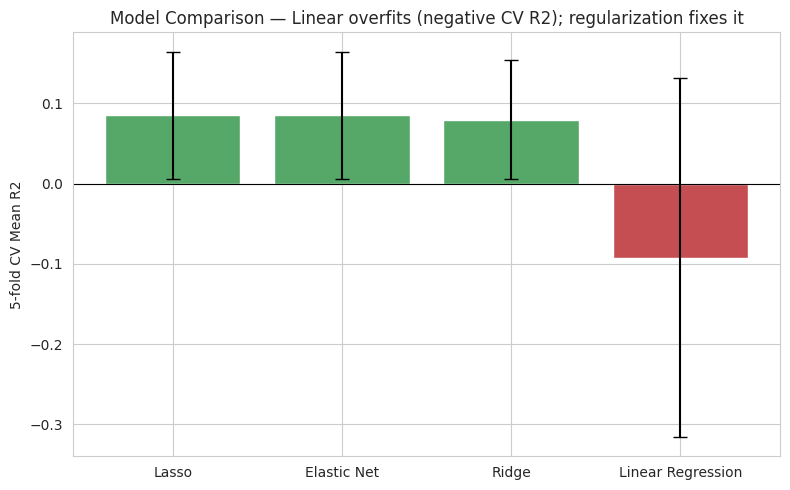

In [15]:
plt.figure(figsize=(8, 5))
order = comparison.sort_values('CV Mean R2', ascending=False).index
values = comparison.loc[order, 'CV Mean R2'].astype(float)
errs = comparison.loc[order, 'CV Std R2'].astype(float)
colors = ['#55A868' if v > 0 else '#C44E52' for v in values]
plt.bar(order, values, yerr=errs, capsize=5, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('5-fold CV Mean R2')
plt.title('Model Comparison — Linear overfits (negative CV R2); regularization fixes it')
plt.tight_layout()
plt.show()

## 11. Multicollinearity Check (VIF)

To be precise about *why* regularization helps here: it is **not** severe multicollinearity (no VIF is extreme), it is **high dimensionality relative to sample size**, with a couple of moderately correlated pairs on top.

In [16]:
Xt_train = preprocessor.fit_transform(X_train)   # fit ONLY on training data, for this diagnostic
feat_names = preprocessor.get_feature_names_out()
Xt_train_df = pd.DataFrame(Xt_train, columns=feat_names)

vif_df = pd.DataFrame({
    'feature': feat_names,
    'VIF': [variance_inflation_factor(Xt_train_df.values, i) for i in range(Xt_train_df.shape[1])]
}).sort_values('VIF', ascending=False)

vif_df.head(10)

,feature,VIF
10,onehot__Fjob_other,5.467697
11,onehot__Fjob_services,4.832487
8,onehot__Mjob_teacher,3.103958
27,scaler__Medu,2.938955
7,onehot__Mjob_services,2.689276
6,onehot__Mjob_other,2.560430
12,onehot__Fjob_teacher,2.494688
36,scaler__Walc,2.460172
5,onehot__Mjob_health,2.332021
9,onehot__Fjob_health,2.157683


Max VIF is well under the common VIF>10 (or even VIF>5) danger threshold — confirming multicollinearity alone is not the driver of Linear Regression's poor CV performance. The real driver is the **feature-to-sample-size ratio** (38 predictors vs 316 rows), which the coefficient analysis below makes very concrete.

In [17]:
print('Medu vs Fedu correlation:', df['Medu'].corr(df['Fedu']).round(3))
print('Dalc vs Walc correlation:  ', df['Dalc'].corr(df['Walc']).round(3))

Medu vs Fedu correlation: 0.623
Dalc vs Walc correlation:   0.648


## 12. Coefficient / Feature Importance Analysis

In [18]:
models_for_coefs = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=results['Ridge']['best_params']['model__alpha'], random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=results['Lasso']['best_params']['model__alpha'], random_state=RANDOM_STATE, max_iter=20000),
    'Elastic Net': ElasticNet(
        alpha=results['Elastic Net']['best_params']['model__alpha'],
        l1_ratio=results['Elastic Net']['best_params']['model__l1_ratio'],
        random_state=RANDOM_STATE, max_iter=20000
    ),
}

coef_table = None
for name, m in models_for_coefs.items():
    pipe = Pipeline([('pre', preprocessor), ('model', m)])
    pipe.fit(X_train, y_train)
    names = pipe.named_steps['pre'].get_feature_names_out()
    s = pd.Series(pipe.named_steps['model'].coef_, index=names, name=name)
    coef_table = s.to_frame() if coef_table is None else coef_table.join(s)

print(f'Total features: {len(coef_table)}')
print(f"Non-zero in Lasso: {(coef_table['Lasso'].abs() > 1e-6).sum()}")
print(f"Non-zero in Elastic Net: {(coef_table['Elastic Net'].abs() > 1e-6).sum()}")
coef_table.round(3)

Total features: 39
Non-zero in Lasso: 2
Non-zero in Elastic Net: 2


,Linear,Ridge,Lasso,Elastic Net
onehot__school_MS,0.726,0.038,-0.000,-0.000
onehot__sex_M,1.496,0.280,0.000,0.000
onehot__address_U,0.344,0.084,0.000,0.000
onehot__famsize_LE3,0.696,0.189,0.000,0.000
onehot__Pstatus_T,-0.645,-0.126,-0.000,-0.000
onehot__Mjob_health,1.122,0.146,0.000,0.000
onehot__Mjob_other,-0.268,-0.096,-0.000,-0.000
onehot__Mjob_services,0.674,0.169,0.000,0.000
onehot__Mjob_teacher,-1.108,-0.068,-0.000,-0.000
onehot__Fjob_health,0.145,0.028,0.000,0.000


In [19]:
surviving = coef_table[(coef_table['Lasso'].abs() > 1e-6) | (coef_table['Elastic Net'].abs() > 1e-6)]
print('Features that survive Lasso/Elastic Net regularization (non-zero coefficient):')
surviving[['Linear', 'Ridge', 'Lasso', 'Elastic Net']].round(3)

Features that survive Lasso/Elastic Net regularization (non-zero coefficient):


,Linear,Ridge,Lasso,Elastic Net
scaler__Medu,0.504,0.372,0.203,0.207
scaler__failures,-1.362,-0.876,-1.163,-1.161


**This is the most interview-worthy finding in the whole project.** Out of 38 encoded features:

- Linear Regression assigns a non-zero coefficient to **every single one** — including features that are almost certainly noise (e.g. `guardian_other`, individual `Fjob`/`Mjob` categories) — because unregularized OLS has no mechanism to say "this feature doesn't matter."
- **Lasso and Elastic Net reduce this to just 2 features**: `failures` (number of past class failures — strong **negative** coefficient) and `Medu` (mother's education level — moderate **positive** coefficient). Every other coefficient is shrunk to exactly zero.
- These 2 surviving features have an intuitive, defensible real-world story: students with more past failures tend to score lower, and higher parental (mother's) education level is associated with a modest positive effect — both are well-documented findings in the educational-outcomes literature this dataset comes from.
- Ridge, by contrast, keeps all 38 features but shrinks their magnitudes (compare the `Ridge` column to `Linear` above) — it never performs selection, which is the core mechanistic difference from Lasso/Elastic Net illustrated concretely here.

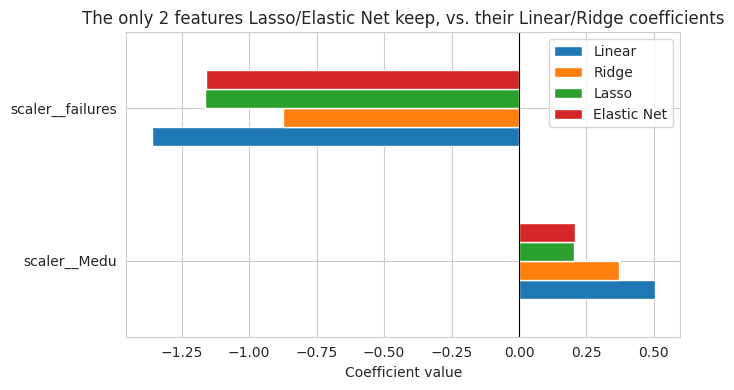

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
surviving[['Linear', 'Ridge', 'Lasso', 'Elastic Net']].plot(kind='barh', ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('The only 2 features Lasso/Elastic Net keep, vs. their Linear/Ridge coefficients')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

## 13. Residual & Error Analysis (best model: Lasso)

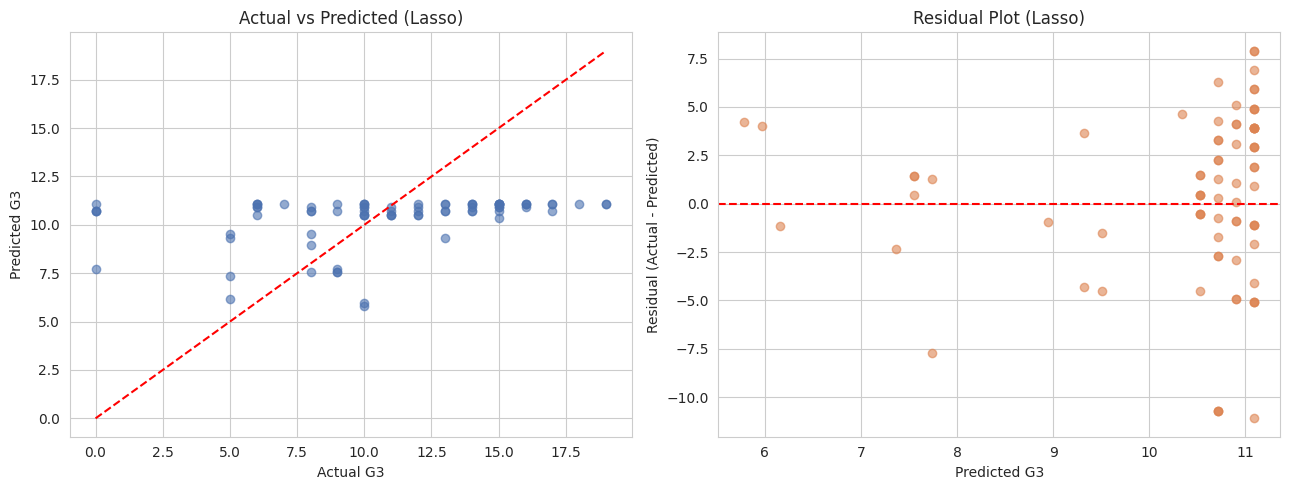

Residual mean: 0.422
Residual std : 4.304


In [21]:
y_pred_lasso = best_lasso.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_lasso, alpha=0.6, color='#4C72B0')
lims = [min(y_test.min(), y_pred_lasso.min()), max(y_test.max(), y_pred_lasso.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual G3')
axes[0].set_ylabel('Predicted G3')
axes[0].set_title('Actual vs Predicted (Lasso)')

residuals = y_test - y_pred_lasso
axes[1].scatter(y_pred_lasso, residuals, alpha=0.6, color='#DD8452')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted G3')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot (Lasso)')

plt.tight_layout()
plt.show()

print(f'Residual mean: {residuals.mean():.3f}')
print(f'Residual std : {residuals.std():.3f}')

The predictions cluster fairly tightly around the middle of the grade range (a consequence of only 2 predictors surviving), and the wide scatter in the Actual-vs-Predicted plot visually confirms the low R² — this model captures a real but modest signal (past failures and mother's education), not the full picture of what drives a student's final grade. That is an honest, defensible characterization to give in an interview rather than an overclaim.

## 14. Final Model Selection

- **Linear Regression** must be ruled out on this feature set — negative CV R² is disqualifying, not just "slightly worse."
- **Ridge** fixes the generalization problem (positive CV R²) but keeps all 38 features, offering no interpretability gain and requiring a very large alpha (200) to compensate for the many noisy predictors.
- **Lasso** and **Elastic Net** both fix generalization *and* deliver a highly interpretable 2-feature model, with Elastic Net's best `l1_ratio` (0.99) landing close to pure Lasso — consistent with the multicollinearity here being mild rather than severe.

**Recommendation: Lasso** (or equivalently, the near-Lasso Elastic Net) is the best choice for this project — it achieves the best combination of generalization (positive CV R²) and interpretability (2 clearly meaningful features out of 38), which is the strongest, most defensible story for this dataset.

## 15. Conclusion

Unlike the earlier version of this project (8-column dataset with two near-duplicate, highly-correlated score features), this UCI-based rebuild uses a genuinely higher-dimensional feature set (38 encoded predictors, 316 training rows) where regularization has real, measurable value: Linear Regression's cross-validated R² is negative (severe overfitting), while Ridge, Lasso, and Elastic Net all restore positive generalization performance. Lasso and Elastic Net additionally perform automatic feature selection, reducing 38 candidate predictors down to 2 interpretable ones (`failures`, `Medu`) with real-world-defensible signs. This provides a concrete, reproducible, and honestly-reported demonstration of why regularized linear models are used in practice.